# <span style="color:rgb(213,80,0)">最適化問題その１（パラメーター推定）</span>

MATLABにはさまざまな最適化ツール群が備わっております。それを活用例として、微分方程式で表される反応モデル内の未知のパラメーター推定法に学習します。

## 1. 微分方程式のパラメーター推定手順

最適化手法には、多種類ありますが、パラメーター推定のための基本動作は共通しております。

1.1.  微分方程式と実験データの準備:

必要となるのは、推定したいパラメーターを含む微分方程式のモデルと実測値です。﻿

1.2. 目的関数の定義:

微分方程式のモデルをMATLABで解き、シミュレーション結果を得ます。シミュレーション結果と実験データの差分を計算し、これを誤差関数（目的関数）として定義します。﻿

1.3. 最適化問題の設定:

目的関数を最小化するパラメーターを探索する問題として、MATLABの最適化関数（fmincon、lsqnonlinなど）にこの目的関数とパラメーターの初期値を渡します。﻿必要に応じて、パラメーターの制約条件を設定することもできます。

1.4. 最適化の実行:

MATLABの最適化スクリプトを実行します。関数は、誤差関数を最小化するパラメーターの値を返します。﻿

このような流れです。MATLABには最適化Toolが多種備わっており、Global最適化も実施することができます。

本講義では、よく使われる最小二乗法ではなく、fminsearchというコマンドで実行します。

\-\-\- \-\-\- \-\-\-

【MATLABディスクトップ版をインストールした方へ】

fminsearchを使うには、[Optimization Toolbox](https://jp.mathworks.com/help/releases/R2025b/optim/getting-started-with-optimization-toolbox.html)を追加する必要があります。本稿末尾をみてください。

\-\-\- \-\-\- \-\-\-

## 2. 微分方程式の数値解（ODE)と実測値とのフィッティングによる速度定数推算：

前回は微分方程式の数値解法による可逆反応の解析について勉強しました。本日は、同じ可逆反応の数値解と実測値のフィッティングによる速度定数パラメーターを推定します。

　最初に対象とする反応モデルは以下の通りです。

## $$\mathrm{A}~~\rightleftharpoons ~~~\mathrm{B$$}

### Mathematical model

$$\left\lbrace \begin{array}{ll} \frac{dC_{\mathrm{A}} }{dt} & =-r_1 +r_2 \newline \frac{dC_{\mathrm{B}} }{dt} & =r_1 -r_2  \end{array}\right.$$

Thus

$$\left\lbrace \begin{array}{ll} \frac{dC_{\mathrm{A}} }{dt} & =-k_1 C_{\mathrm{A}} +k_2 C_{\mathrm{B}} \newline \frac{dC_{\mathrm{B}} }{dt} & =k_1 C_{\mathrm{A}} -k_2 C_{\mathrm{B}}  \end{array}\right.$$

メインのスクリプト例を以下に示します。data.txtファイルには、時間、CA、CBの濃度の時間変化実測値が掲載されております。このスクリプトファイル実行時に読み込みますので、同じフォルダーに保管しておいてください。


In [1]:
%% ============================================================
%  可逆反応 A ⇌ B の速度定数 k1, k2 を fminsearch で推定
% ============================================================


clear; clc; close all;


%% --- 実測データの読み込み ---
% data.txt: [time[s], CA[mol/L], CB[mol/L]]
data = readmatrix('data.txt');
t_exp = data(:,1);
CA_exp = data(:,2);
CB_exp = data(:,3);


%% --- 初期条件 ---
CA0 = CA_exp(1);
CB0 = CB_exp(1);
y0 = [CA0; CB0];


%% --- 初期推定値 [k1, k2] ---
k_init = [0.1, 0.1];  % 適宜変更


%% --- fminsearch による最適化 ---
optfun = @(k) objective_fun(k, t_exp, y0, CA_exp, CB_exp);
[k_opt, fval] = fminsearch(optfun, k_init);


fprintf('最適化結果:\n');
fprintf('  k1 = %.6f\n', k_opt(1));
fprintf('  k2 = %.6f\n', k_opt(2));
fprintf('  残差平方和 = %.6e\n', fval);


%% --- 最適パラメータでモデル計算 ---
[~, y_fit] = ode45(@(t,y) reactionODE(t,y,k_opt), t_exp, y0);
CA_fit = y_fit(:,1);
CB_fit = y_fit(:,2);


%% --- 結果の可視化 ---
figure;
subplot(2,1,1);
plot(t_exp, CA_exp, 'o', 'DisplayName','Exp A');
hold on;
plot(t_exp, CA_fit, '-', 'LineWidth',1.5, 'DisplayName','Fit A');
xlabel('Time [s]');
ylabel('C_A [mol/L]');
legend; grid on;


subplot(2,1,2);
plot(t_exp, CB_exp, 'o', 'DisplayName','Exp B');
hold on;
plot(t_exp, CB_fit, '-', 'LineWidth',1.5, 'DisplayName','Fit B');
xlabel('Time [s]');
ylabel('C_B [mol/L]');
legend; grid on;


sgtitle('Reversible Reaction Fit (fminsearch)');


%% ============================================================
% --- 関数定義 ---
%% ============================================================


function dydt = reactionODE(~, y, k)
    % 反応速度式
    CA = y(1); CB = y(2);
    k1 = k(1); k2 = k(2);
    dCA = -k1*CA + k2*CB;
    dCB =  k1*CA - k2*CB;
    dydt = [dCA; dCB];
end


function SSE = objective_fun(k, t_exp, y0, CA_exp, CB_exp)
    % モデルを解いて二乗誤差を計算
    if any(k < 0)
        SSE = 1e6;  % 負の定数を防ぐためのペナルティ
        return;
    end
    [~, y_model] = ode45(@(t,y) reactionODE(t,y,k), t_exp, y0);
    CA_model = y_model(:,1);
    CB_model = y_model(:,2);
    SSE = sum((CA_model - CA_exp).^2 + (CB_model - CB_exp).^2);
end




<pre>
 %% --- 実測データの読み込み ---
        data = readmatrix('data.txt');
</pre>

でdata.txtの値をn行３列のdataという名前の行列として読み込みます.

試しに、コマンドウィンドウでdata = readmatrix('data.txt'); と入力し、ENTERで実行してください。

ワークスペースにdataという51x3の行列が現れます。コマンドウィンドウに data と入力し、ENTERを押してください。

その中身が表示されます。次にコマンドウインドウに　data(:,1)と入力実行してください。時間データのみ抽出されます。

従って　スクリプト10行目にあるように

　t\_exp = data(:,1);

とおけば、t\_expという変数に割り当てられます。11,12行目は同じように濃度データを抽出して、変数を割り当てております。

<pre>
          #初期条 ---
        CA0 = CA_exp(1);
        CB0 = CB_exp(1);
        y0 = [CA0; CB0];
</pre>

はもうお分かりと思います。CA0にCA\_expの最初の値が割り当てられます。CB0なども同じ要領です。

<pre>
%%--- 初期推定値 [k1, k2] ---
    k_init = [0.1, 0.1];  % 適宜変更
</pre>

速度定数２つの初期推定値を与えます。

<pre>
%% --- fminsearch による最適化 ---
optfun = @(k) objective_fun(k, t_exp, y0, CA_exp, CB_exp);
[k_opt, fval] = fminsearch(optfun, k_init);
</pre>

ここが大切なところです。目的関数をここではobjective\_funという名前で定義しております。その中身は、function  objective\_funと定義するfunctionのところを見てください。

<pre>
[k_opt, fval] = fminsearch(optfun, k_init);
</pre>

fminsearchは勾配を使わない単純形法（Nelder–Mead simplex method）を使って最適化問題を解きます。ニュートン法のように、勾配法では、初期値と解曲線によっては、初期推定値からどんどん、真の解から遠ざかる方向に、解を探索してしまう、欠点があります。この心配がないのがfiminsearchのメリットになります。

optfunの目的関数の最小値をk\_initiの初期値から開始し、探索していきます。

　これ以降の説明は割愛します。

作業１：上記のコードを実行し、以下のことを確認してください。

1. 実測値と計算値が一致しているのがわかると思います。
2. $k1,k2$ の値は、変数名 k\_opt に格納されております。k\_optは1x2のベクトルで, k1とk2はk\_opt(1) , k\_opt(2)とコマンドウィンドウに入力すれば出力されます。
3. k\_intの値とk1,k2の値をメモしておいてください。

作業2 ：k\_init = \[0.1, 0.1\]が初期値になります。この値を色々と変化させて、k\_init, k1,k2のリストを作成してください。グラフを見て、実測値と計算値の一致度も確認してください。

# <span style="color:rgb(213,80,0)">課題１：</span>

#### 以上の作業１、２を実施して、思ったことを以下にテキスト入力してください。

課題１の回答はこちらにテキスト入力してください。

# <span style="color:rgb(213,80,0)">課題2 </span>

#### 　作業２において、例えばk\_init = \[10, 10\]と真の値とかけ離れている場合、カーブフィッティングがうまくいきません。そこで、算出された速度パラメーターも使えません。

#### 　パラメーターの初期値が全く予想できないような場合、少しでも、真の値に近づけるには、どのような方法が考えられますか。何を見てもかまいませんので、調べてみてください。その方法を以下に記述してください。（別紙の添付でも構いません）

課題２回答欄

# <span style="color:rgb(213,80,0)">次にWebClassの問２の課題もあります。</span>

MATLAB Toolboxの追加方法

1. PC版MATLABを起動
2. 「ホーム」タブを選択
3. 「アドオンの検索」でOptimization Toolboxを入力
4. リストの中からOptimization Toolboxをクリック
5. Optimization Toolbox画面で「インストール」をクリックでインストールされます。

<p style="text-align:left">
   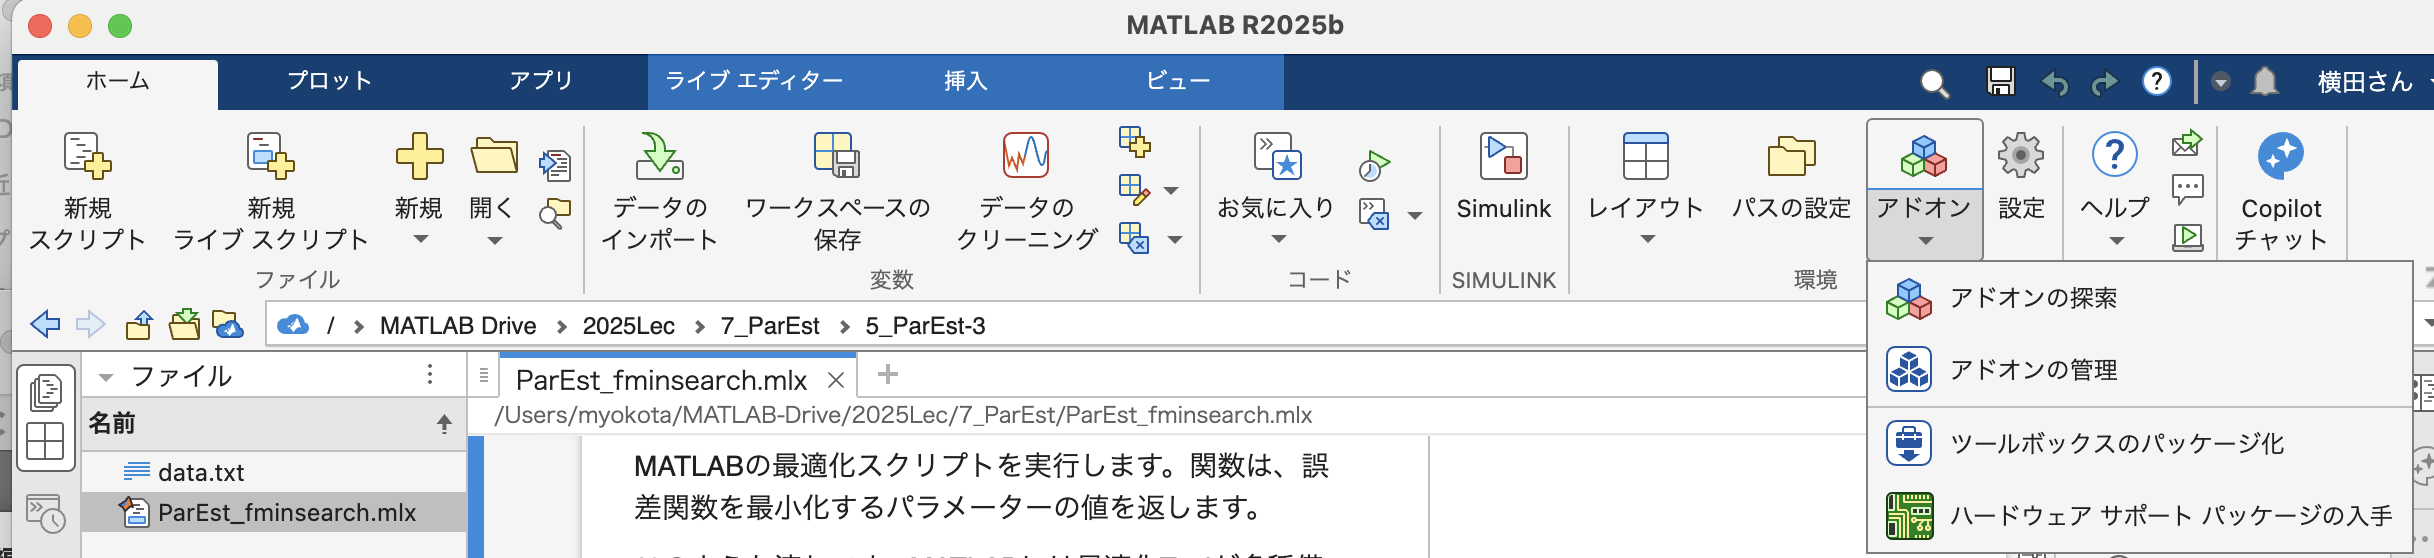
</p>

<p style="text-align:left">
   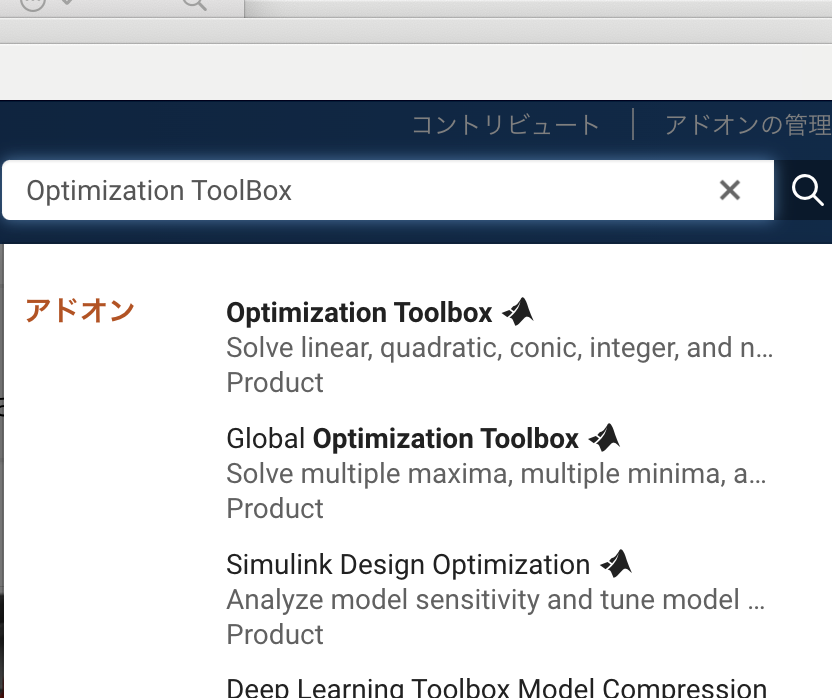
</p>